# Vertex Reconstruction and Track PID — reviewed version

This notebook is a cleaned version of `vertex_reco_and_classification.ipynb`.

Main fixes:
- removes broken split cells / dangling parentheses
- makes the ROOT file path portable
- keeps original track indices when tracks are skipped
- separates **truth-assisted validation** from **reco-only inference**
- adds a simple reco-only vertex grouping option based on reconstructed track start positions

In [12]:
import uproot
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

print("Imports successful")

Imports successful


## 1. Load ROOT file

In [13]:
# Change this path if needed.
# Keep the ROOT file in the same folder as this notebook if possible.
file_path = Path("cut2.root")

# Fallback to Windows path used in the original notebook
if not file_path.exists():
    file_path = Path(r"C:\MY_CODES\NIRAB_DAI\Cut2.root")

if not file_path.exists():
    raise FileNotFoundError(
        "Could not find cut2.root. Put it next to this notebook or edit file_path."
    )

f = uproot.open(file_path)
print("Opened:", file_path)
print("Keys:", f.keys())

t_rc = f["Reco_Tree;2"] if "Reco_Tree;2" in f else f["Reco_Tree"]
t_tr = f["Truth_Info;2"] if "Truth_Info;2" in f else f["Truth_Info"]

print("Reco entries:", t_rc.num_entries)
print("Truth entries:", t_tr.num_entries)

Opened: C:\MY_CODES\NIRAB_DAI\Cut2.root
Keys: ['Reco_Tree;2', 'Reco_Tree;1', 'Truth_Info;2', 'Truth_Info;1', 'Line_Candidates;2', 'Line_Candidates;1']
Reco entries: 1380
Truth entries: 1380


## 2. Load required branches

In [14]:
reco_branches = ["TrackHitPos", "TrackHitEnergies", "nTracks"]
truth_branches = [
    "TrueVtxX", "TrueVtxY", "TrueVtxZ",
    "TrueVtxID", "RecoTrackPrimaryParticleVtxId",
    "RecoTrackPrimaryParticlePDG"
]

missing_reco = [b for b in reco_branches if b not in t_rc.keys()]
missing_truth = [b for b in truth_branches if b not in t_tr.keys()]
if missing_reco:
    raise KeyError(f"Missing Reco_Tree branches: {missing_reco}")
if missing_truth:
    raise KeyError(f"Missing Truth_Info branches: {missing_truth}")

rc_arr = t_rc.arrays(reco_branches)
tr_arr = t_tr.arrays(truth_branches)

n_events = min(len(rc_arr), len(tr_arr))
print(f"Loaded {n_events} matched reco/truth events")

Loaded 1380 matched reco/truth events


## 3. Geometry helpers

In [15]:
def valid_hit_mask(hits):
    """Return mask for real [x,y,z,t] hits, removing ROOT padding/sentinel values."""
    hits = np.asarray(hits)
    if hits.ndim != 2 or hits.shape[1] < 3:
        return np.zeros(len(hits), dtype=bool)
    xyz = hits[:, :3]
    # Keep hits that are not sentinel/padding.
    # Some files use -999999 or -99999000 style values.
    return np.all(xyz > -9e7, axis=1) & np.any(np.abs(xyz) > 0, axis=1)

def fit_3d_line(hits):
    """Fit a 3D line to hits using PCA/SVD. Returns point, unit direction, mean squared transverse residual."""
    hits = np.asarray(hits)[:, :3]
    if len(hits) < 2:
        return None

    mean = np.mean(hits, axis=0)
    centered = hits - mean

    # SVD is stable for line direction
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    direction = direction / np.linalg.norm(direction)

    # Force direction roughly downstream in z for consistent angle calculations
    if direction[2] < 0:
        direction = -direction

    transverse = centered - np.outer(centered @ direction, direction)
    mean_residual = float(np.mean(np.sum(transverse**2, axis=1)))
    return mean, direction, mean_residual

def reconstruct_vertex_from_lines(lines):
    """Least-squares closest point to many 3D lines: sum(I-ddT)V = sum(I-ddT)p."""
    if len(lines) == 0:
        return None
    if len(lines) == 1:
        # With one line, the vertex is not constrained. Return upstream-most hit/point proxy elsewhere if possible.
        return lines[0]["point"]

    A = np.zeros((3, 3))
    b = np.zeros(3)
    for line in lines:
        p = line["point"]
        d = line["direction"]
        P = np.eye(3) - np.outer(d, d)
        A += P
        b += P @ p

    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(A, b, rcond=None)[0]

def dca_point_to_line(vtx, p, d):
    diff = vtx - p
    return np.linalg.norm(diff - (diff @ d) * d)

def get_track_start_end(hits):
    hits = np.asarray(hits)[:, :3]
    start = hits[np.argmin(hits[:, 2])]
    end = hits[np.argmax(hits[:, 2])]
    return start, end

## 4. Extract fitted tracks while preserving original track index

In [16]:
def extract_event_tracks(event_id, min_hits=2):
    """Return fitted reco tracks for one event, preserving original track_idx."""
    n_tracks = int(rc_arr["nTracks"][event_id])
    out = []

    for track_idx in range(n_tracks):
        hits4 = ak.to_numpy(rc_arr["TrackHitPos"][event_id][track_idx])
        energies = ak.to_numpy(rc_arr["TrackHitEnergies"][event_id][track_idx])

        mask = valid_hit_mask(hits4)
        hits4 = hits4[mask]
        energies = energies[mask]

        if len(hits4) < min_hits:
            continue

        fit = fit_3d_line(hits4[:, :3])
        if fit is None:
            continue

        p, d, resid = fit
        start, end = get_track_start_end(hits4[:, :3])

        out.append({
            "track_idx": track_idx,
            "hits4": hits4,
            "hits": hits4[:, :3],
            "energies": energies,
            "point": p,
            "direction": d,
            "straightness": resid,
            "start": start,
            "end": end,
        })

    return out

# Quick sanity check
for eid in range(min(10, n_events)):
    tracks = extract_event_tracks(eid)
    if tracks:
        print("First non-empty event:", eid, "tracks:", len(tracks))
        break

First non-empty event: 0 tracks: 2


## 5. Truth helpers for simulation validation

In [17]:
def get_truth_vertex_map(event_id):
    """Map TrueVtxID -> np.array([x,y,z]) for one event."""
    vtx_ids = ak.to_list(tr_arr["TrueVtxID"][event_id])
    xs = ak.to_list(tr_arr["TrueVtxX"][event_id])
    ys = ak.to_list(tr_arr["TrueVtxY"][event_id])
    zs = ak.to_list(tr_arr["TrueVtxZ"][event_id])
    return {vid: np.array([x, y, z], dtype=float) for vid, x, y, z in zip(vtx_ids, xs, ys, zs)}

def get_track_truth_info(event_id, track_idx):
    """Return truth vertex ID and PDG for a reco track index, if available."""
    vtx_ids = ak.to_list(tr_arr["RecoTrackPrimaryParticleVtxId"][event_id])
    pdgs = ak.to_list(tr_arr["RecoTrackPrimaryParticlePDG"][event_id])
    tv_id = vtx_ids[track_idx] if track_idx < len(vtx_ids) else None
    pdg = pdgs[track_idx] if track_idx < len(pdgs) else None
    return tv_id, pdg

## 6. Vertex validation: global vs truth-grouped

In [19]:
global_residuals = []
truth_group_residuals = []

global_reco_vertices = []
global_true_vertices = []

cluster_reco_vertices = []
cluster_true_vertices = []

for event_id in range(n_events):
    tracks = extract_event_tracks(event_id)
    if len(tracks) == 0:
        continue

    truth_vtx_map = get_truth_vertex_map(event_id)

    # Global vertex: all reco tracks in event forced into one vertex
    if len(tracks) == 1:
        est_global = tracks[0]["start"]
    else:
        est_global = reconstruct_vertex_from_lines(tracks)

    # Compare global vertex to first track's truth vertex only as a diagnostic
    tv_id0, _ = get_track_truth_info(event_id, tracks[0]["track_idx"])

    if tv_id0 in truth_vtx_map:
        true_global = truth_vtx_map[tv_id0]

        global_residuals.append(est_global - true_global)
        global_reco_vertices.append(est_global.copy())
        global_true_vertices.append(true_global.copy())

    # Truth-assisted grouping: validation only, not usable on real data
    groups = {}

    for trk in tracks:
        tv_id, _ = get_track_truth_info(event_id, trk["track_idx"])

        if tv_id in truth_vtx_map:
            groups.setdefault(tv_id, []).append(trk)

    for tv_id, group_tracks in groups.items():
        if len(group_tracks) == 1:
            est_cluster = group_tracks[0]["start"]
        else:
            est_cluster = reconstruct_vertex_from_lines(group_tracks)

        true_cluster = truth_vtx_map[tv_id]

        truth_group_residuals.append(est_cluster - true_cluster)
        cluster_reco_vertices.append(est_cluster.copy())
        cluster_true_vertices.append(true_cluster.copy())

global_res = np.asarray(global_residuals)
truth_group_res = np.asarray(truth_group_residuals)

global_reco_vertices = np.asarray(global_reco_vertices)
global_true_vertices = np.asarray(global_true_vertices)

cluster_reco_vertices = np.asarray(cluster_reco_vertices)
cluster_true_vertices = np.asarray(cluster_true_vertices)


def print_residual_summary(name, res):
    print(f"\n{name} residuals: N={len(res)}")

    if len(res) == 0:
        return

    labels = ["dX", "dY", "dZ"]

    for i, lab in enumerate(labels):
        print(
            f"  {lab}: mean={np.mean(res[:, i]):9.2f} mm, "
            f"std={np.std(res[:, i]):9.2f} mm"
        )


print_residual_summary("Global event vertex", global_res)
print_residual_summary("Truth-grouped vertex validation", truth_group_res)

print("\nReco/true vertex arrays:")
print("  global_reco_vertices:", global_reco_vertices.shape)
print("  global_true_vertices: ", global_true_vertices.shape)
print("  cluster_reco_vertices:", cluster_reco_vertices.shape)
print("  cluster_true_vertices: ", cluster_true_vertices.shape)


Global event vertex residuals: N=1380
  dX: mean=    39.11 mm, std=  1194.43 mm
  dY: mean=  -175.89 mm, std=  1650.93 mm
  dZ: mean=  1427.70 mm, std=  5955.86 mm

Truth-grouped vertex validation residuals: N=2038
  dX: mean=   -18.18 mm, std=   387.68 mm
  dY: mean=  -152.08 mm, std=   920.38 mm
  dZ: mean=   765.95 mm, std=  4191.81 mm

Reco/true vertex arrays:
  global_reco_vertices: (1380, 3)
  global_true_vertices:  (1380, 3)
  cluster_reco_vertices: (2038, 3)
  cluster_true_vertices:  (2038, 3)


## 7. Simple reco-only grouping by track start proximity

In [20]:
def reco_group_tracks_by_start(tracks, radius_mm=300.0):
    """Greedy clustering of tracks by upstream start-point proximity. Simple baseline only."""
    groups = []
    for trk in sorted(tracks, key=lambda t: t["start"][2]):
        assigned = False
        for group in groups:
            center = np.mean([g["start"] for g in group], axis=0)
            if np.linalg.norm(trk["start"] - center) < radius_mm:
                group.append(trk)
                assigned = True
                break
        if not assigned:
            groups.append([trk])
    return groups

# Compare reco-only groups to truth composition for a few events
for event_id in range(min(20, n_events)):
    tracks = extract_event_tracks(event_id)
    if len(tracks) < 2:
        continue
    groups = reco_group_tracks_by_start(tracks, radius_mm=300.0)
    print(f"Event {event_id}: {len(tracks)} tracks -> {len(groups)} reco groups")
    for gi, group in enumerate(groups):
        truth_ids = [get_track_truth_info(event_id, t["track_idx"])[0] for t in group]
        print("  group", gi, "track_idx", [t["track_idx"] for t in group], "truth_vtx_ids", truth_ids)
    break

Event 0: 2 tracks -> 2 reco groups
  group 0 track_idx [0] truth_vtx_ids [100]
  group 1 track_idx [1] truth_vtx_ids [102]


## 8. Event display

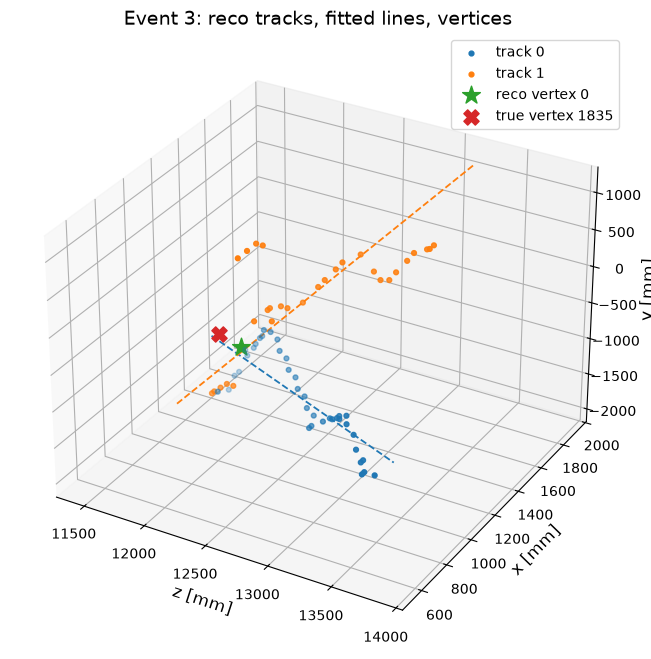

In [21]:
def plot_event_3d(event_id, use_reco_groups=False, radius_mm=300.0):
    tracks = extract_event_tracks(event_id)
    if not tracks:
        print("No tracks in event", event_id)
        return

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for trk in tracks:
        h = trk["hits"]
        ax.scatter(h[:, 2], h[:, 0], h[:, 1], s=12, label=f"track {trk['track_idx']}")

        p, d = trk["point"], trk["direction"]
        z_min, z_max = np.min(h[:, 2]), np.max(h[:, 2])
        z_steps = np.linspace(z_min - 200, z_max + 200, 100)
        if abs(d[2]) > 1e-6:
            t_steps = (z_steps - p[2]) / d[2]
            x_line = p[0] + t_steps * d[0]
            y_line = p[1] + t_steps * d[1]
            ax.plot(z_steps, x_line, y_line, "--", linewidth=1.3)

    if use_reco_groups:
        groups = reco_group_tracks_by_start(tracks, radius_mm=radius_mm)
    else:
        groups = [tracks]

    for gi, group in enumerate(groups):
        est = group[0]["start"] if len(group) == 1 else reconstruct_vertex_from_lines(group)
        ax.scatter([est[2]], [est[0]], [est[1]], marker="*", s=180, label=f"reco vertex {gi}")

    truth_vtx_map = get_truth_vertex_map(event_id)
    used_truth_ids = set()
    for trk in tracks:
        tv_id, _ = get_track_truth_info(event_id, trk["track_idx"])
        if tv_id in truth_vtx_map and tv_id not in used_truth_ids:
            v = truth_vtx_map[tv_id]
            ax.scatter([v[2]], [v[0]], [v[1]], marker="X", s=120, label=f"true vertex {tv_id}")
            used_truth_ids.add(tv_id)

    ax.set_xlabel("z [mm]")
    ax.set_ylabel("x [mm]")
    ax.set_zlabel("y [mm]")
    ax.set_title(f"Event {event_id}: reco tracks, fitted lines, vertices")
    ax.legend()
    plt.show()

# Change event_id as needed
plot_event_3d(event_id=3, use_reco_groups=True)

## 9. PID-like feature extraction

In [22]:
features = []

for event_id in range(n_events):
    tracks = extract_event_tracks(event_id)
    if not tracks:
        continue

    # Reco-only global/group vertex for inference features
    # For baseline, use global vertex; later replace with reco groups.
    reco_vertex = tracks[0]["start"] if len(tracks) == 1 else reconstruct_vertex_from_lines(tracks)

    for trk in tracks:
        hits = trk["hits"]
        energies = trk["energies"]
        start = trk["start"]
        end = trk["end"]
        p = trk["point"]
        d = trk["direction"]

        chord_length = float(np.linalg.norm(end - start))
        # Polyline length is often a better length estimate for scattered tracks
        if len(hits) >= 2:
            order = np.argsort(hits[:, 2])
            polyline_length = float(np.sum(np.linalg.norm(np.diff(hits[order], axis=0), axis=1)))
        else:
            polyline_length = chord_length

        z_depth = float(np.max(hits[:, 2]) - np.min(hits[:, 2]))
        nhits = int(len(hits))
        total_energy = float(np.sum(energies))
        dedx_chord = total_energy / chord_length if chord_length > 0 else np.nan
        dedx_poly = total_energy / polyline_length if polyline_length > 0 else np.nan
        dca_reco = dca_point_to_line(reco_vertex, p, d)

        tv_id, pdg = get_track_truth_info(event_id, trk["track_idx"])
        is_muon = int(abs(pdg) == 13) if pdg is not None else np.nan

        features.append({
            "event_id": event_id,
            "track_idx": trk["track_idx"],
            "truth_vtx_id": tv_id,
            "pdg": pdg,
            "is_muon": is_muon,
            "chord_length": chord_length,
            "polyline_length": polyline_length,
            "nhits": nhits,
            "z_depth": z_depth,
            "straightness_mse": trk["straightness"],
            "total_energy": total_energy,
            "dedx_chord": dedx_chord,
            "dedx_poly": dedx_poly,
            "dca_to_reco_vertex": dca_reco,
        })

df = pd.DataFrame(features)
df.to_csv("track_features_reviewed.csv", index=False)
print("Saved:", "track_features_reviewed.csv")
print("Rows:", len(df))
df.head()

Saved: track_features_reviewed.csv
Rows: 2915


,event_id,track_idx,truth_vtx_id,pdg,is_muon,chord_length,polyline_length,nhits,z_depth,straightness_mse,total_energy,dedx_chord,dedx_poly,dca_to_reco_vertex
0,0,0,100,13,1,3972.477295,4179.552734,48,3840.0,13072.366211,123.977600,0.031209,0.029663,658.957736
1,0,1,102,13,1,1715.931885,3737.833496,22,1520.0,147343.078125,49.127827,0.028630,0.013143,658.957744
2,1,0,798,13,1,2004.673218,2614.980469,38,1780.0,26208.156250,126.040039,0.062873,0.048199,922.027926
3,1,1,800,2212,0,1337.829590,1462.322998,17,1280.0,621.923340,45.426617,0.033955,0.031065,922.027900
4,2,0,1639,13,1,1391.409912,2687.278320,19,1280.0,16685.160156,53.272919,0.038287,0.019824,342.256241


## 10. Feature summaries

chord_length                                        polyline_length  \
               count         mean          std       median           count   
is_muon                                                                       
0               1506  1493.041470   595.177009  1381.366516            1506   
1               1409  2491.541129  1152.593549  2281.555176            1409   

                                               nhits             ...  \
                mean          std       median count       mean  ...   
is_muon                                                          ...   
0        2223.084659  1192.492061  1983.191040  1506  17.853918  ...   
1        3212.413813  1612.825998  2905.077393  1409  33.567069  ...   

        dedx_chord           dedx_poly                                \
               std    median     count      mean       std    median   
is_muon                                                                
0         0.023559  0.025994      1506  0.022873  0.018753  0.017824   
1         0.012725  0.034971      1409  0.030222  0.011758  0.028232   

        dca_to_reco_vertex                                      
                     count        mean         std      median  
is_muon                                                         
0                     1506  355.524671  556.514512  107.379265  
1                     1409  717.286957  715.999070  463.545201  

[2 rows x 36 columns]

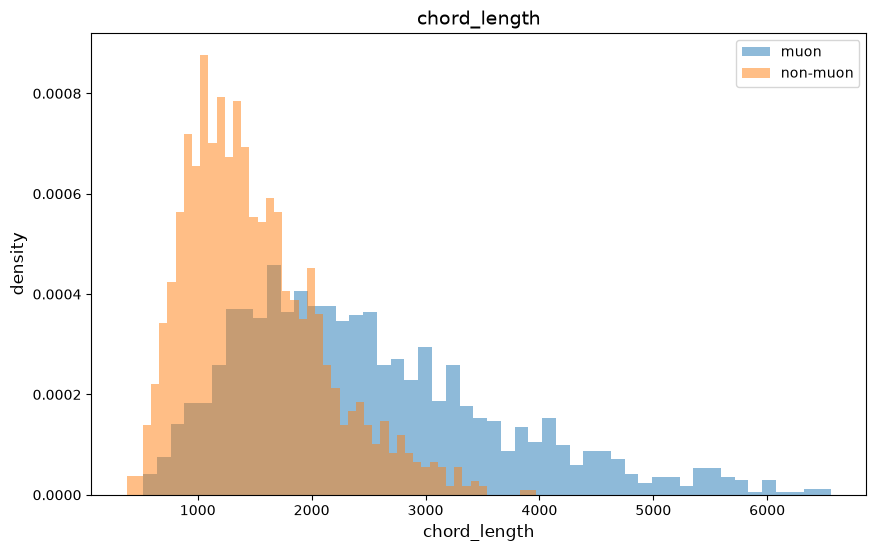

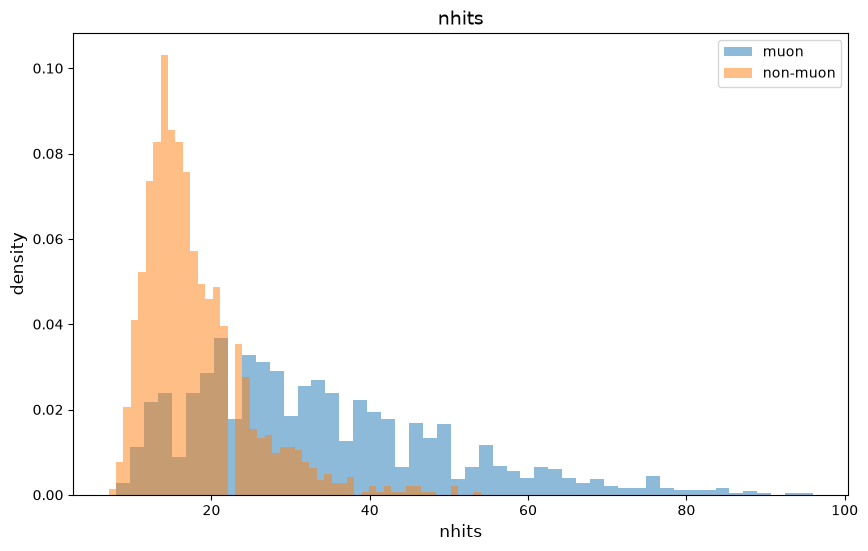

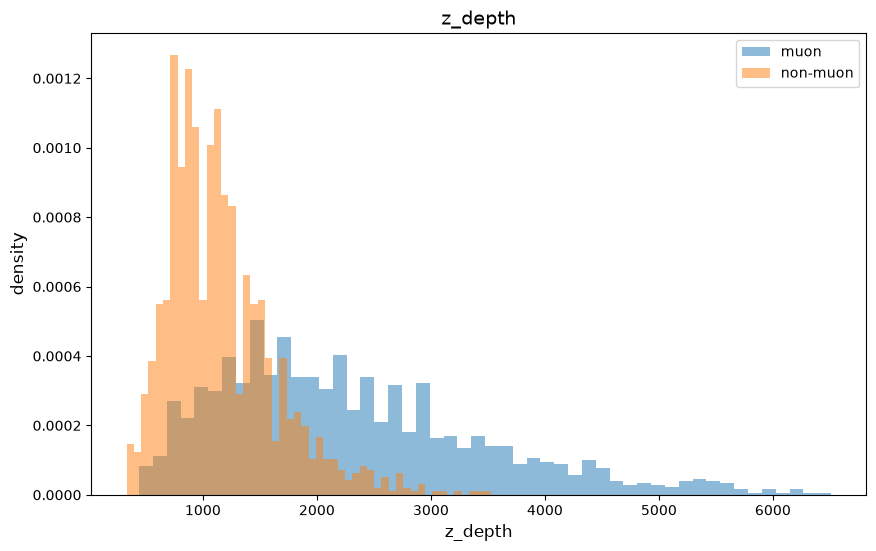

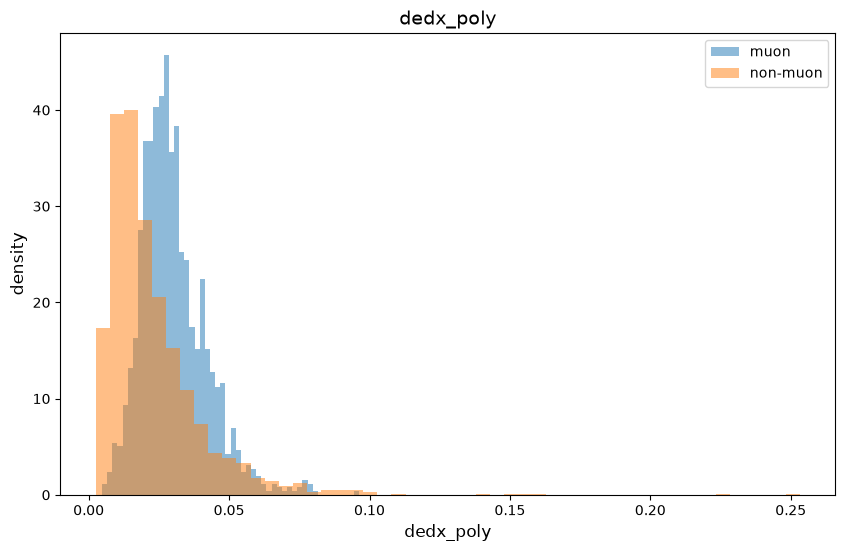

In [23]:
if len(df) > 0 and "is_muon" in df:
    numeric_cols = [
        "chord_length", "polyline_length", "nhits", "z_depth",
        "straightness_mse", "total_energy", "dedx_chord", "dedx_poly",
        "dca_to_reco_vertex"
    ]
    display(df.groupby("is_muon")[numeric_cols].agg(["count", "mean", "std", "median"]))

    for col in ["chord_length", "nhits", "z_depth", "dedx_poly"]:
        plt.figure()
        for label, name in [(1, "muon"), (0, "non-muon")]:
            vals = df.loc[df["is_muon"] == label, col].dropna()
            if len(vals):
                plt.hist(vals, bins=50, density=True, alpha=0.5, label=name)
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("density")
        plt.legend()
        plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reco_true_vertex_scatter(reco_vertices, true_vertices, title_prefix="Clustered"):
    if len(reco_vertices) == 0 or len(true_vertices) == 0:
        print("No reco/true vertex pairs available to plot.")
        return

    labels = ["X", "Y", "Z"]
    units = "mm"

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, ax in enumerate(axes):
        x = true_vertices[:, i]
        y = reco_vertices[:, i]

        ax.scatter(x, y, s=10, alpha=0.6)
        
        lo = min(np.min(x), np.min(y))
        hi = max(np.max(x), np.max(y))
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="Ideal: reco = true")

        # Optional linear fit
        if len(x) > 1:
            m, b = np.polyfit(x, y, 1)
            xx = np.linspace(lo, hi, 200)
            ax.plot(xx, m * xx + b, color="black", linewidth=1.2,
                    label=f"Fit: y={m:.3f}x + {b:.1f}")

            corr = np.corrcoef(x, y)[0, 1]
        else:
            corr = np.nan

        residual = y - x
        mean_res = np.mean(residual)
        std_res = np.std(residual)

        ax.set_title(
            f"{title_prefix} Vertex {labels[i]}\n"
            f"mean Δ={mean_res:.1f} {units}, std={std_res:.1f} {units}, r={corr:.3f}"
        )
        ax.set_xlabel(f"True {labels[i]} ({units})")
        ax.set_ylabel(f"Reco {labels[i]} ({units})")
        ax.legend()

    fig.suptitle(f"{title_prefix} Reco vs True Vertex Coordinates", fontsize=16)
    plt.tight_layout()
    plt.show()

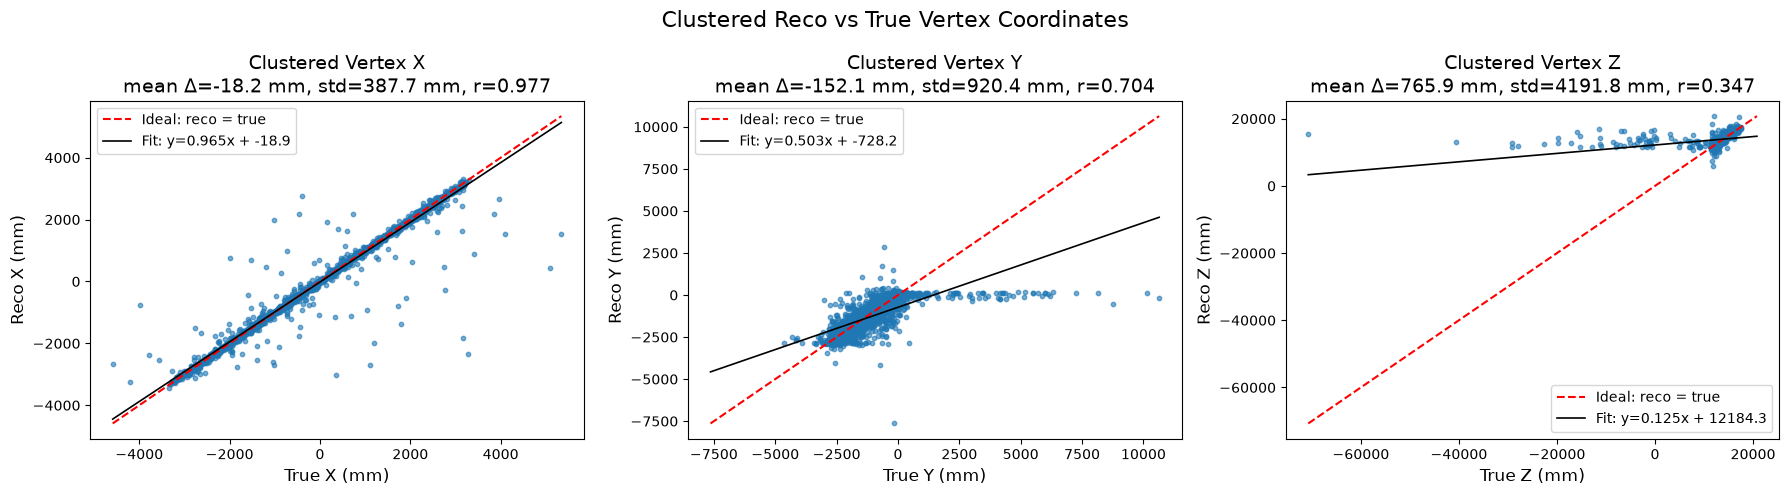

In [25]:
plot_reco_true_vertex_scatter(
    cluster_reco_vertices,
    cluster_true_vertices,
    title_prefix="Clustered"
)

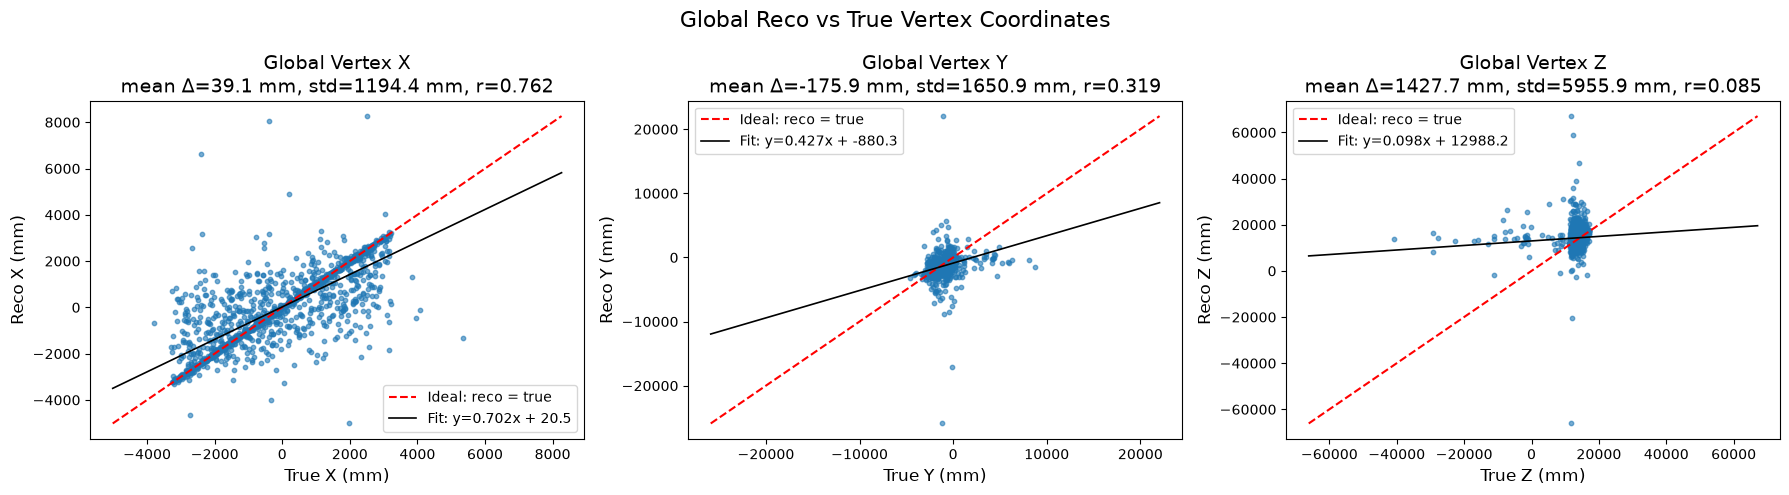

In [26]:
plot_reco_true_vertex_scatter(
    global_reco_vertices,
    global_true_vertices,
    title_prefix="Global"
)

In [27]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_reco_true_vertex_3d(reco_vertices, true_vertices, title="Reco vs True Vertices (3D)"):
    if len(reco_vertices) == 0 or len(true_vertices) == 0:
        print("No reco/true vertex pairs available to plot.")
        return

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(true_vertices[:, 2], true_vertices[:, 0], true_vertices[:, 1],
               s=20, alpha=0.7, label="True vertices")
    ax.scatter(reco_vertices[:, 2], reco_vertices[:, 0], reco_vertices[:, 1],
               s=20, alpha=0.7, label="Reco vertices")

    # draw line between each true/reco pair
    for t, r in zip(true_vertices, reco_vertices):
        ax.plot([t[2], r[2]], [t[0], r[0]], [t[1], r[1]],
                color="gray", alpha=0.3, linewidth=0.8)

    ax.set_xlabel("Z (mm)")
    ax.set_ylabel("X (mm)")
    ax.set_zlabel("Y (mm)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

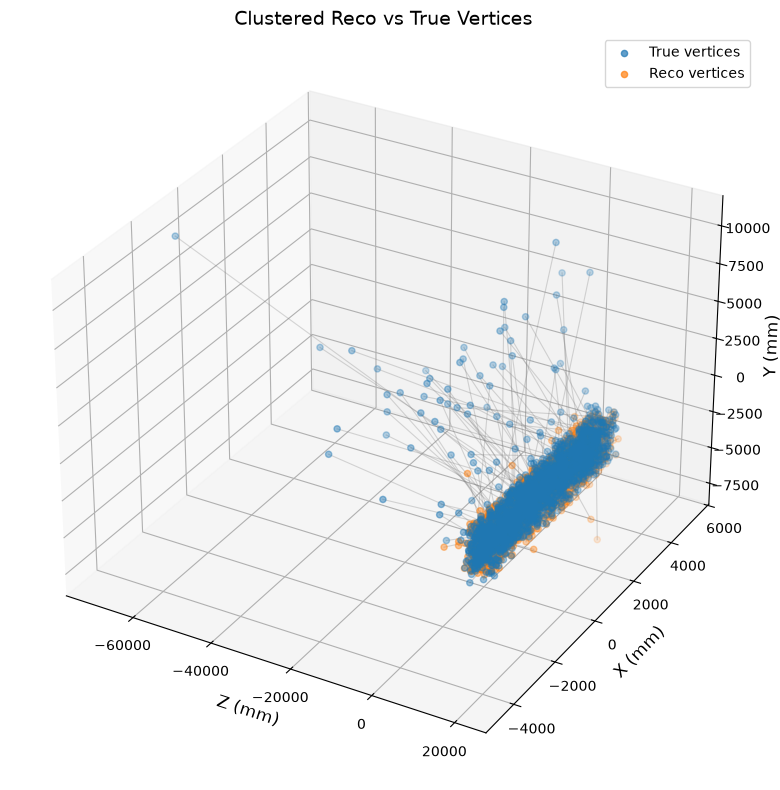

In [28]:
plot_reco_true_vertex_3d(
    cluster_reco_vertices,
    cluster_true_vertices,
    title="Clustered Reco vs True Vertices"
)

## Important interpretation

- The **truth-grouped vertex** is validation only. It is not a reco-only algorithm.
- For real data, replace truth grouping with a reconstructed grouping method, such as start-point clustering, DCA clustering, or a Hough/RANSAC-style multi-vertex finder.
- If the fitted vertex is upstream in LAr while hits are only in TMS, the y-coordinate can be unstable because small angular errors become large extrapolation errors.
- Use `Truth_Info` to label performance in simulation, but do not include truth variables as inputs in a reco-only classifier.